In [42]:
import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DIRECTORY = pathlib.Path("~/Box/dsi-core/11th-hour/good-food-purchasing/nov2025-dataset").expanduser()

In [3]:
columns = [
    "Food Product Group",
    "Food Product Category",
    "Primary Food Product Category",
    "Basic Type",
    "Sub-Type",
    "Flavor/Cut",
    "Shape",
    "Skin",
    "Seed/Bone",
    "Processing",
    "Cooked/Cleaned",
    "WG/WGR",
    "Dietary Concern",
    "Additives",
    "Dietary Accommodation",
    "Frozen",
    "Packaging",
    "Commodity",
]
column_data = {f"want_{c}": [] for c in columns} | {f"got_{c}": [] for c in columns}

with open(DIRECTORY / "test-results-try3.jsonl") as file:
    for line in file:
        data = json.loads(line)
        if data["status_code"] != 200 or data["deformed_output"] is not None:
            continue
        expected_output = data["expected_output"]
        actual_output = data["actual_output"]
        for c in columns:
            column_data[f"want_{c}"].append(expected_output.get(c, None))
            column_data[f"got_{c}"].append(actual_output.get(c, None))

df = pd.DataFrame(column_data)

In [162]:
def draw_hierarchical(major_column, minor_column, titlesep=0.25, figsize=(2, 10), distribute_major=False):
    counts = df.groupby([major_column, minor_column]).size().reset_index(name="count")
    minor_totals = counts.groupby(minor_column)["count"].sum()
    counts["fraction"] = counts["count"] / counts[minor_column].map(minor_totals)
    counts = counts.merge(counts.groupby(minor_column)["count"].max().to_frame("max_count"), left_on=minor_column, right_index=True)

    major_pos = {}
    minor_pos = {}

    seen_major = set()
    major_to_draw = None
    index = 1
    for _, row in counts.iterrows():
        if row[major_column] not in seen_major:
            major_to_draw = row[major_column]
            seen_major.add(row[major_column])
        if row["count"] == row["max_count"]:
            if major_to_draw is not None:
                major_pos[major_to_draw] = index
            major_to_draw = None
            minor_pos[row[minor_column]] = index
            index += 1

    if distribute_major:
        major_pos = dict(zip(major_pos.keys(), np.linspace(min(minor_pos.values()), max(minor_pos.values()), len(major_pos))))

    fig, ax = plt.subplots(figsize=figsize)

    title = major_column
    if title.startswith("want_"):
        title = title[5:]
    ax.text(0, titlesep, title, ha="right", va="center", weight="bold", c="grey")
    for x, i in major_pos.items():
        ax.text(0, -i, x, ha="right", va="center")

    title = minor_column
    if title.startswith("want_"):
        title = title[5:]
    ax.text(0.3, titlesep, title, ha="left", va="center", weight="bold", c="grey")
    for x, i in minor_pos.items():
        ax.text(0.3, -i, x, ha="left", va="center")

    for _, row in counts.iterrows():
        p1 = major_pos.get(row[major_column])
        p2 = minor_pos.get(row[minor_column])
        if p1 is not None and p2 is not None:
            ax.plot([0.01, 0.29], [-p1, -p2], c="black", alpha=row["fraction"])

    plt.axis("off")

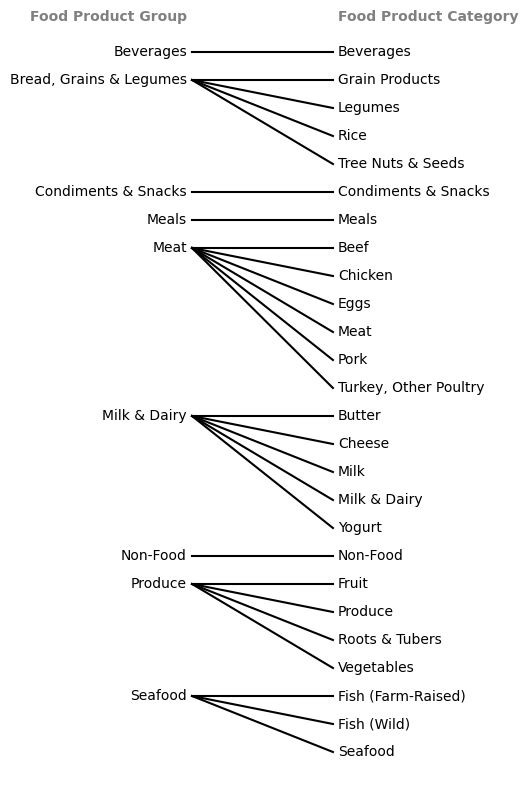

In [164]:
draw_hierarchical("want_Food Product Group", "want_Food Product Category")

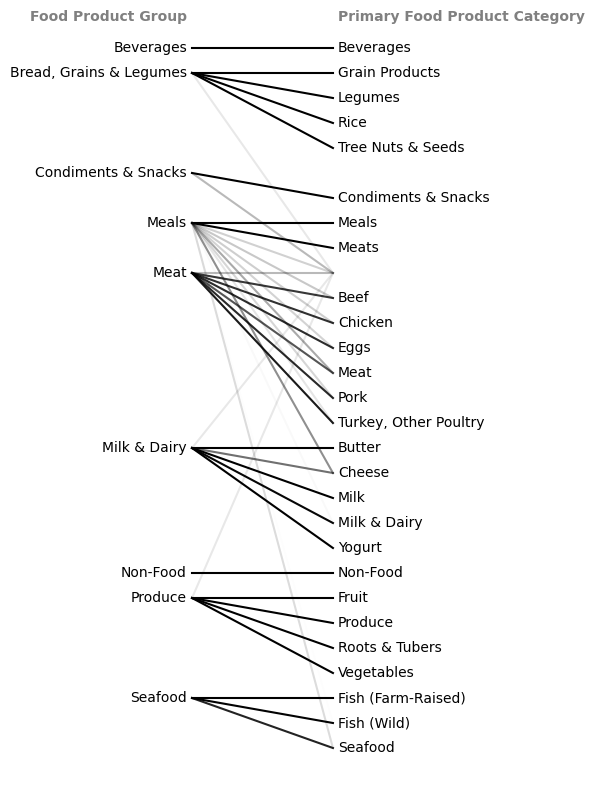

In [170]:
draw_hierarchical("want_Food Product Group", "want_Primary Food Product Category")

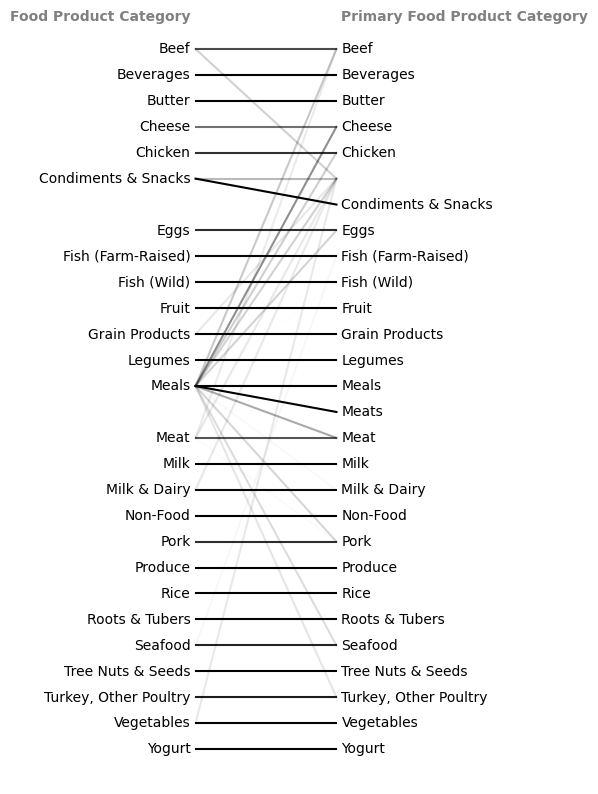

In [165]:
draw_hierarchical("want_Food Product Category", "want_Primary Food Product Category")

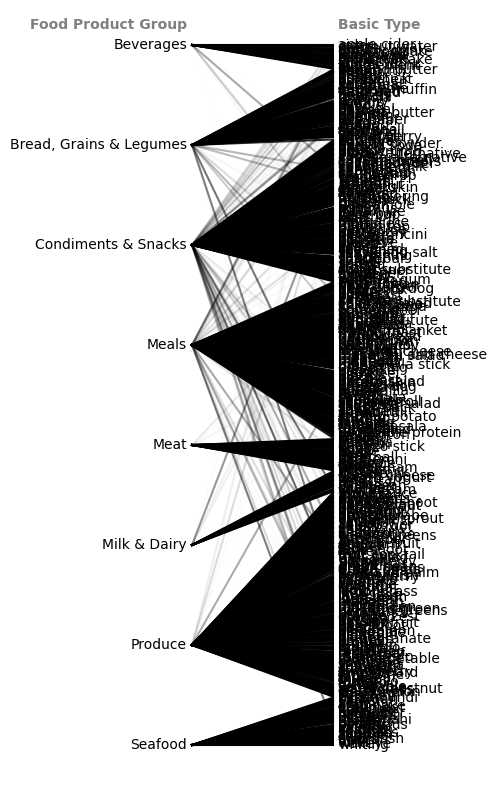

In [167]:
draw_hierarchical("want_Food Product Group", "want_Basic Type", titlesep=15, distribute_major=True)

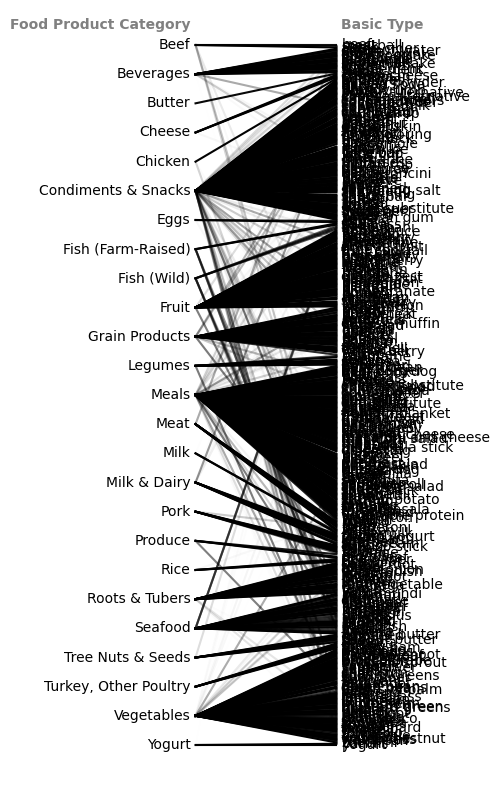

In [168]:
draw_hierarchical("want_Food Product Category", "want_Basic Type", titlesep=15, distribute_major=True)

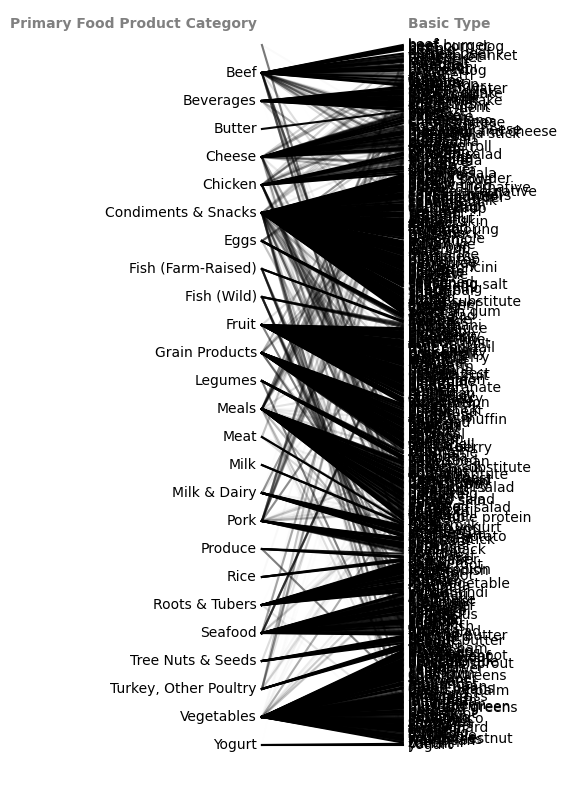

In [169]:
draw_hierarchical("want_Primary Food Product Category", "want_Basic Type", titlesep=15, distribute_major=True)